# Mood-Based Artistic Style Transfer
**Pipeline:** Upload photo → Mood Classifier → Style Recommendation → Style Transfer → Output

## Sections
1. Setup & Installs
2. Dataset Download & Prep
3. Feature Extraction
4. Naive Baseline
5. Classical ML Classifier
6. Deep Learning Classifier (EfficientNet)
7. Model Evaluation & Comparison
8. Style Transfer Setup
9. Full Pipeline Test
10. Error Analysis & Experiment

## 1. Setup & Installs

In [1]:
!pip install -q torch torchvision timm scikit-learn matplotlib seaborn pillow numpy pandas requests tqdm tensorflow tensorflow_hub kaggle scikit-image

In [2]:
import os, io, json, requests, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
from tqdm import tqdm
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import timm
import tensorflow as tf
import tensorflow_hub as hub

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None"}')

Device: cuda
GPU: Tesla T4


## 2. Dataset Download & Prep
We use FER2013 (facial emotion dataset) and collapse 7 emotion classes into 5 mood classes:
happy, calm, melancholic, energetic, dramatic

In [3]:
DIRS = ['data/raw', 'data/processed', 'data/outputs', 'models/classifier', 'models/style_weights', 'notebooks']
for d in DIRS:
    os.makedirs(d, exist_ok=True)
print('Directories created.')

Directories created.


In [4]:
# Set USE_KAGGLE=True and upload kaggle.json to get real FER2013 data
# Otherwise a synthetic dataset is used for pipeline testing
USE_KAGGLE = True

if USE_KAGGLE:
    from google.colab import files
    print('Upload kaggle.json:')
    files.upload()
    !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
    !kaggle datasets download -d msambare/fer2013 -p data/raw --unzip
    print('FER2013 downloaded.')
else:
    print('Using synthetic data. Set USE_KAGGLE=True for real data.')
    print('Download FER2013 from: https://www.kaggle.com/datasets/msambare/fer2013')

Upload kaggle.json:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
100% 60.3M/60.3M [00:03<00:00, 20.2MB/s]

FER2013 downloaded.


In [5]:
import os
from pathlib import Path

for split in ['train', 'test']:
    split_path = Path('data/raw') / split
    print(f'\n{split.upper()} SET:')
    total = 0
    for emotion_dir in sorted(split_path.iterdir()):
        if emotion_dir.is_dir():
            count = len(list(emotion_dir.glob('*.jpg')) + list(emotion_dir.glob('*.png')))
            print(f'  {emotion_dir.name}: {count} images')
            total += count
    print(f'  TOTAL: {total}')


TRAIN SET:
  angry: 3995 images
  disgust: 436 images
  fear: 4097 images
  happy: 7215 images
  neutral: 4965 images
  sad: 4830 images
  surprise: 3171 images
  TOTAL: 28709

TEST SET:
  angry: 958 images
  disgust: 111 images
  fear: 1024 images
  happy: 1774 images
  neutral: 1233 images
  sad: 1247 images
  surprise: 831 images
  TOTAL: 7178


In [6]:
# Clean one-to-one mapping — one emotion per mood, no merging
# disgust and fear excluded: disgust has too few examples (436),
# fear is visually ambiguous and overlaps with surprise
EMOTION_LABEL_TO_MOOD = {
    'happy':    'happy',
    'neutral':  'calm',
    'sad':      'melancholic',
    'surprise': 'energetic',
    'angry':    'dramatic'
}

MOOD_TO_STYLE = {
    'happy':       'monet',
    'calm':        'hokusai',
    'melancholic': 'vangogh',
    'energetic':   'kandinsky',
    'dramatic':    'munch'
}

MOODS = ['happy', 'calm', 'melancholic', 'energetic', 'dramatic']
print('Mood classes:', MOODS)
print('Mood to Style:', MOOD_TO_STYLE)
print('Excluded: disgust (too few samples), fear (visually ambiguous)')

Mood classes: ['happy', 'calm', 'melancholic', 'energetic', 'dramatic']
Mood to Style: {'happy': 'monet', 'calm': 'hokusai', 'melancholic': 'vangogh', 'energetic': 'kandinsky', 'dramatic': 'munch'}
Excluded: disgust (too few samples), fear (visually ambiguous)


In [7]:
import os
from pathlib import Path

for split in ['train', 'test']:
    split_path = Path('data/raw') / split
    print(f'\n{split.upper()} SET:')
    total = 0
    for emotion_dir in sorted(split_path.iterdir()):
        if emotion_dir.is_dir():
            count = len(list(emotion_dir.glob('*.jpg')) + list(emotion_dir.glob('*.png')))
            print(f'  {emotion_dir.name}: {count} images')
            total += count
    print(f'  TOTAL: {total}')


TRAIN SET:
  angry: 3995 images
  disgust: 436 images
  fear: 4097 images
  happy: 7215 images
  neutral: 4965 images
  sad: 4830 images
  surprise: 3171 images
  TOTAL: 28709

TEST SET:
  angry: 958 images
  disgust: 111 images
  fear: 1024 images
  happy: 1774 images
  neutral: 1233 images
  sad: 1247 images
  surprise: 831 images
  TOTAL: 7178


In [8]:
def fer_row_to_image(pixel_str, size=48):
    """Convert FER2013 pixel string to RGB numpy array."""
    pixels = np.array(pixel_str.split(), dtype=np.uint8).reshape(size, size)
    return np.stack([pixels, pixels, pixels], axis=-1)

def load_fer2013_from_folders(root='data/raw', split='train'):
    """
    Load FER2013 image folders and map emotions to moods.
    Uses full data — no subsampling. Disgust and fear excluded
    due to low sample count and visual ambiguity respectively.
    """
    records = []
    split_path = Path(root) / split
    for emotion_dir in sorted(split_path.iterdir()):
        if not emotion_dir.is_dir():
            continue
        emotion = emotion_dir.name.lower()
        mood = EMOTION_LABEL_TO_MOOD.get(emotion)
        if not mood:
            # Skip disgust and fear intentionally
            continue
        imgs = list(emotion_dir.glob('*.jpg')) + list(emotion_dir.glob('*.png'))
        for img_path in imgs:
            img = Image.open(img_path).convert('L').resize((48, 48))
            pixels = ' '.join(map(str, np.array(img).flatten()))
            records.append({'pixels': pixels, 'mood': mood, 'path': str(img_path)})

    df = pd.DataFrame(records)
    print(f'Loaded {len(df)} images (no subsampling)')
    print(df['mood'].value_counts())
    return df

fer_df = load_fer2013_from_folders('data/raw', split='train')

Loaded 24176 images (no subsampling)
mood
happy          7215
calm           4965
melancholic    4830
dramatic       3995
energetic      3171
Name: count, dtype: int64


In [9]:
print(fer_df['mood'].value_counts())
print(f'Total: {len(fer_df)}')

mood
happy          7215
calm           4965
melancholic    4830
dramatic       3995
energetic      3171
Name: count, dtype: int64
Total: 24176


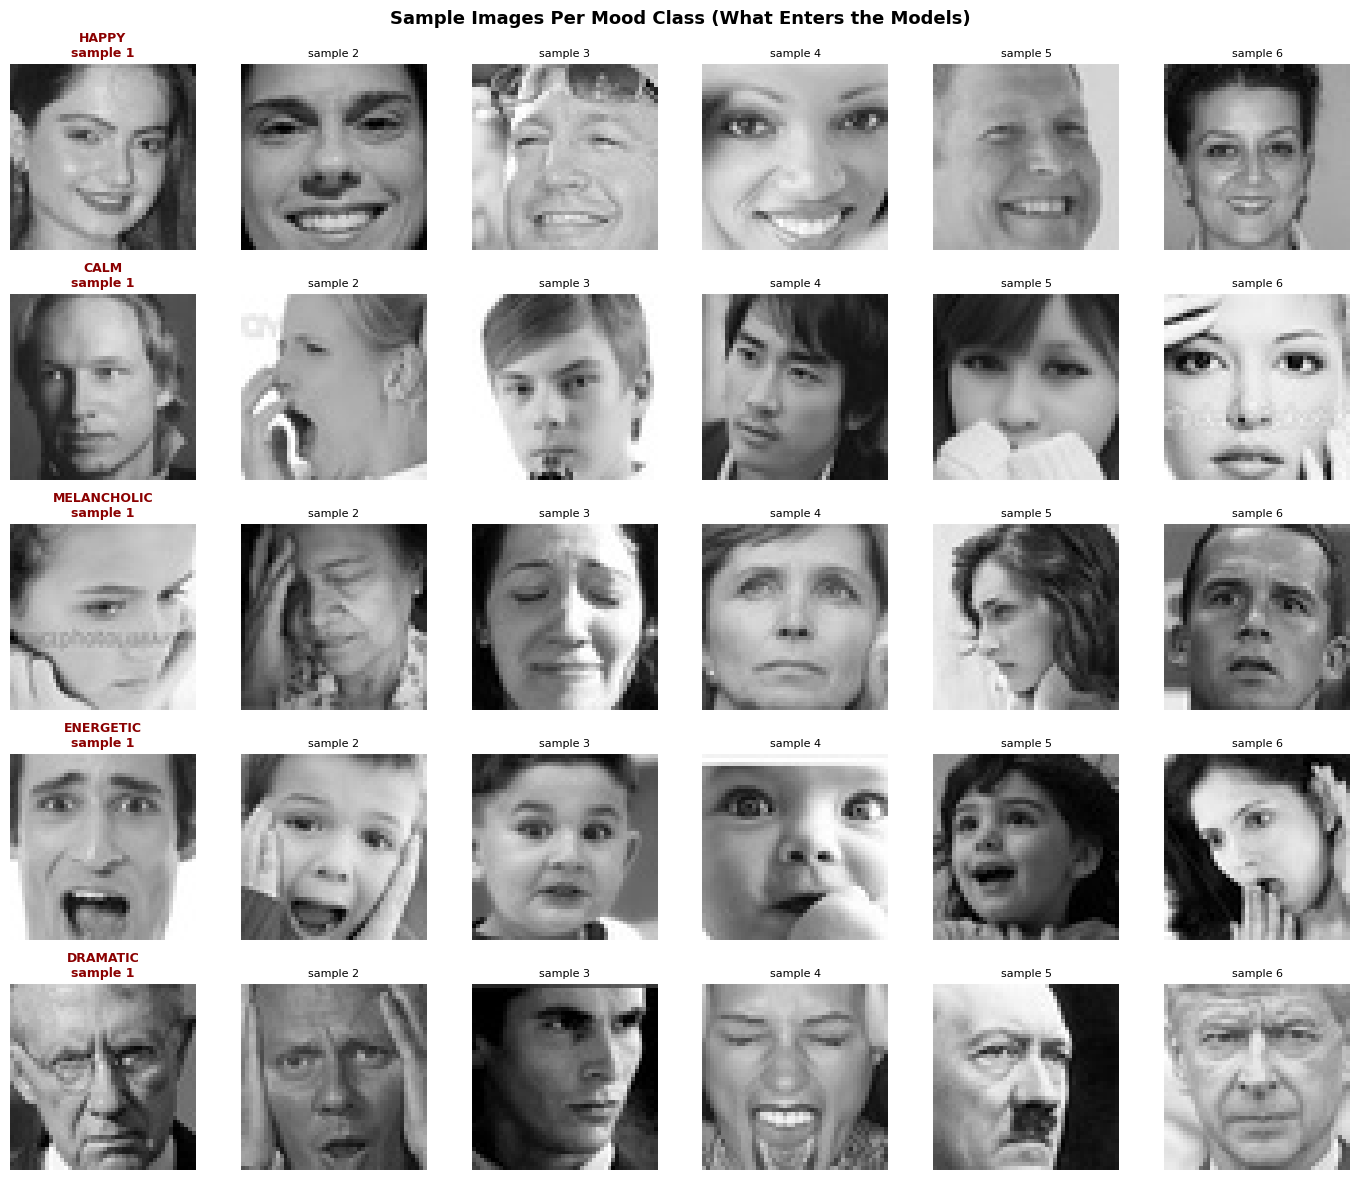

In [10]:
fig, axes = plt.subplots(5, 6, figsize=(14, 12))

for mood_idx, mood in enumerate(MOODS):
    mood_samples = fer_df[fer_df['mood'] == mood].sample(6, random_state=42).reset_index(drop=True)
    for col_idx, (_, row) in enumerate(mood_samples.iterrows()):
        ax = axes[mood_idx, col_idx]
        img = fer_row_to_image(row['pixels'])
        ax.imshow(img, cmap='gray')
        # Show mood label only on first column
        if col_idx == 0:
            ax.set_title(f'{mood.upper()}\nsample 1', fontsize=9, fontweight='bold', color='darkred')
        else:
            ax.set_title(f'sample {col_idx+1}', fontsize=8)
        ax.axis('off')

plt.suptitle('Sample Images Per Mood Class (What Enters the Models)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('data/outputs/sample_inputs.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Feature Extraction
Extract color histograms + HOG features for classical ML models.

In [11]:
from skimage.feature import hog
from skimage.color import rgb2gray

def extract_color_histogram(img_rgb, bins=32):
    """Extract normalized per-channel color histogram (R, G, B)."""
    features = []
    for ch in range(3):
        hist, _ = np.histogram(img_rgb[:, :, ch], bins=bins, range=(0, 256))
        hist = hist.astype(np.float32) / (hist.sum() + 1e-8)
        features.append(hist)
    return np.concatenate(features)

def extract_hog_features(img_rgb):
    """Extract HOG texture/edge features."""
    gray = rgb2gray(img_rgb)
    return hog(gray, orientations=8, pixels_per_cell=(8, 8),
               cells_per_block=(2, 2), feature_vector=True).astype(np.float32)

def extract_brightness_saturation(img_rgb):
    """Extract HSV-based brightness and saturation stats (used by naive baseline)."""
    img_hsv = np.array(Image.fromarray(img_rgb).convert('HSV'))
    mean_hue = img_hsv[:, :, 0].mean() / 255.0
    mean_sat = img_hsv[:, :, 1].mean() / 255.0
    mean_val = img_hsv[:, :, 2].mean() / 255.0
    mean_brightness = img_rgb.mean() / 255.0
    contrast = img_rgb.std() / 255.0
    return np.array([mean_hue, mean_sat, mean_val, mean_brightness, contrast], dtype=np.float32)

def extract_all_features(img_rgb):
    """Combine all features for classical ML."""
    return np.concatenate([
        extract_color_histogram(img_rgb),
        extract_hog_features(img_rgb),
        extract_brightness_saturation(img_rgb)
    ])

# Test
dummy = np.random.randint(0, 255, (64, 64, 3), dtype=np.uint8)
feats = extract_all_features(dummy)
print(f'Feature vector length: {len(feats)}')

Feature vector length: 1669


In [12]:
def build_feature_matrix(df, max_samples=5000):
    """
    Build X (features) and y (labels) from dataframe.
    Caps at max_samples for speed.
    """
    df_sample = df.sample(min(max_samples, len(df)), random_state=42).reset_index(drop=True)
    X, y = [], []
    for _, row in tqdm(df_sample.iterrows(), total=len(df_sample), desc='Extracting features'):
        img = fer_row_to_image(row['pixels'])
        img_resized = np.array(Image.fromarray(img).resize((64, 64)))
        X.append(extract_all_features(img_resized))
        y.append(row['mood'])
    return np.array(X), np.array(y)

print('Building feature matrix...')
X, y = build_feature_matrix(fer_df, max_samples=5000)
print(f'X shape: {X.shape}')

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print('Classes:', le.classes_)

X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f'Train: {len(X_train)}, Val: {len(X_val)}')

Building feature matrix...


Extracting features: 100%|██████████| 5000/5000 [00:17<00:00, 290.46it/s]


X shape: (5000, 1669)
Classes: ['calm' 'dramatic' 'energetic' 'happy' 'melancholic']
Train: 4000, Val: 1000


## 4. Naive Baseline
Rule-based mood prediction using only brightness and saturation. No ML.

In [13]:
def naive_mood_predictor(img_rgb):
    """
    Rule-based mood prediction from color properties.
    Rules:
      High brightness + high saturation -> happy
      High brightness + low saturation  -> calm
      Low brightness + high contrast    -> dramatic
      High saturation + mid brightness  -> energetic
      Otherwise                         -> melancholic
    """
    bs = extract_brightness_saturation(img_rgb)
    hue, sat, val, brightness, contrast = bs

    if brightness > 0.6 and sat > 0.4:
        return 'happy'
    elif brightness > 0.6 and sat <= 0.4:
        return 'calm'
    elif brightness <= 0.4 and contrast > 0.25:
        return 'dramatic'
    elif sat > 0.5 and 0.35 < brightness <= 0.6:
        return 'energetic'
    else:
        return 'melancholic'

def evaluate_naive_baseline(df):
    """Evaluate naive baseline on full dataset."""
    preds, truths = [], []
    for _, row in tqdm(df.iterrows(), total=len(df), desc='Naive baseline'):
        img = fer_row_to_image(row['pixels'])
        img_resized = np.array(Image.fromarray(img).resize((64, 64)))
        preds.append(naive_mood_predictor(img_resized))
        truths.append(row['mood'])
    acc = accuracy_score(truths, preds)
    print(f'Naive Baseline Accuracy: {acc:.4f}')
    print(classification_report(truths, preds, target_names=sorted(MOODS)))
    return {'accuracy': acc, 'predictions': preds, 'truths': truths}

naive_results = evaluate_naive_baseline(fer_df)
NAIVE_ACC = naive_results['accuracy']

Naive baseline: 100%|██████████| 24176/24176 [00:22<00:00, 1090.66it/s]


Naive Baseline Accuracy: 0.2019
              precision    recall  f1-score   support

        calm       0.17      0.20      0.19      4965
    dramatic       0.17      0.04      0.06      3995
   energetic       0.00      0.00      0.00      3171
       happy       0.00      0.00      0.00      7215
 melancholic       0.21      0.77      0.33      4830

    accuracy                           0.20     24176
   macro avg       0.11      0.20      0.12     24176
weighted avg       0.11      0.20      0.11     24176



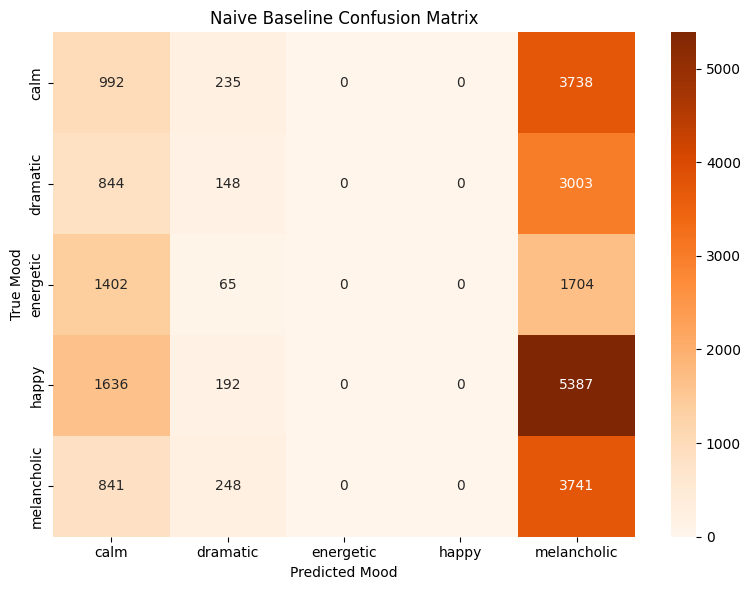

In [14]:
# Naive baseline confusion matrix
naive_preds = naive_results['predictions']
naive_truths = naive_results['truths']

cm_naive = confusion_matrix(naive_truths, naive_preds, labels=sorted(MOODS))
plt.figure(figsize=(8, 6))
sns.heatmap(cm_naive, annot=True, fmt='d', cmap='Oranges',
            xticklabels=sorted(MOODS), yticklabels=sorted(MOODS))
plt.title('Naive Baseline Confusion Matrix')
plt.ylabel('True Mood')
plt.xlabel('Predicted Mood')
plt.tight_layout()
plt.savefig('data/outputs/naive_confusion_matrix.png', dpi=150)
plt.show()

## 5. Classical ML Classifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 2.9 MB/s eta 0:00:00
Running Optuna hyperparameter search for Random Forest (5 trials)...


  0%|          | 0/5 [00:00<?, ?it/s]


Best RF val accuracy: 0.4800
Best RF params: {'n_estimators': 345, 'max_depth': 11, 'min_samples_split': 9, 'min_samples_leaf': 5, 'max_features': 'log2'}

Final Random Forest Val Accuracy: 0.4800
              precision    recall  f1-score   support

        calm       0.47      0.38      0.42       203
    dramatic       0.37      0.20      0.26       168
   energetic       0.65      0.55      0.60       131
       happy       0.51      0.77      0.61       302
 melancholic       0.37      0.33      0.35       196

    accuracy                           0.48      1000
   macro avg       0.47      0.45      0.45      1000
weighted avg       0.47      0.48      0.46      1000



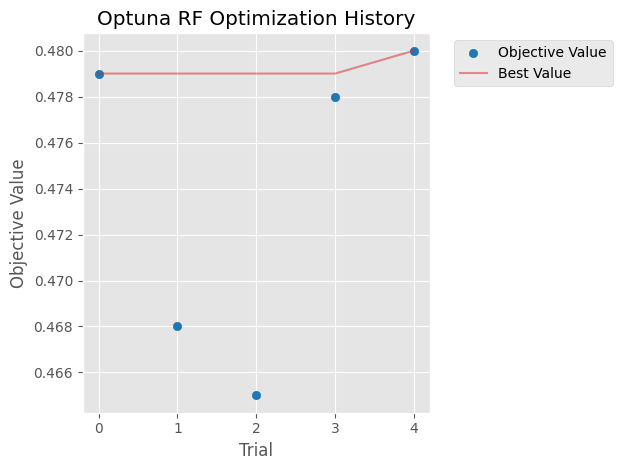

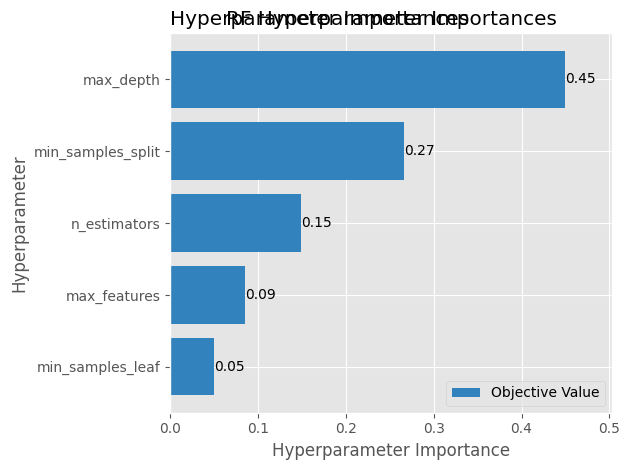

In [15]:
!pip install -q optuna

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective_rf(trial):
    """Optuna objective function for Random Forest hyperparameter tuning."""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
    }
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(**params, class_weight='balanced', random_state=42, n_jobs=-1))
    ])
    pipe.fit(X_train, y_train)
    return accuracy_score(y_val, pipe.predict(X_val))

print('Running Optuna hyperparameter search for Random Forest (5 trials)...')
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=5, show_progress_bar=True)

print(f'\nBest RF val accuracy: {study_rf.best_value:.4f}')
print(f'Best RF params: {study_rf.best_params}')

# Train final RF with best params
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(**study_rf.best_params, class_weight='balanced', random_state=42, n_jobs=-1))
])
rf_pipeline.fit(X_train, y_train)
rf_val_acc = accuracy_score(y_val, rf_pipeline.predict(X_val))
print(f'\nFinal Random Forest Val Accuracy: {rf_val_acc:.4f}')
print(classification_report(y_val, rf_pipeline.predict(X_val), target_names=le.classes_))

# Plot optimization history
optuna.visualization.matplotlib.plot_optimization_history(study_rf)
plt.title('Optuna RF Optimization History')
plt.tight_layout()
plt.savefig('data/outputs/optuna_rf_history.png', dpi=150)
plt.show()

# Plot parameter importances
optuna.visualization.matplotlib.plot_param_importances(study_rf)
plt.title('RF Hyperparameter Importances')
plt.tight_layout()
plt.savefig('data/outputs/optuna_rf_param_importance.png', dpi=150)
plt.show()

SVM Optuna search subset: 5000 samples
Running Optuna hyperparameter search for SVM (10 trials)...


  0%|          | 0/5 [00:00<?, ?it/s]


Best SVM val accuracy: 0.5500
Best SVM params: {'C': 14.461161254048271, 'gamma': 'auto', 'kernel': 'rbf'}
Training final SVM on full data (this may take a few minutes)...

Final SVM Val Accuracy: 0.5620
              precision    recall  f1-score   support

        calm       0.48      0.48      0.48       203
    dramatic       0.44      0.35      0.39       168
   energetic       0.81      0.63      0.71       131
       happy       0.64      0.79      0.71       302
 melancholic       0.45      0.43      0.44       196

    accuracy                           0.56      1000
   macro avg       0.56      0.54      0.55      1000
weighted avg       0.56      0.56      0.56      1000



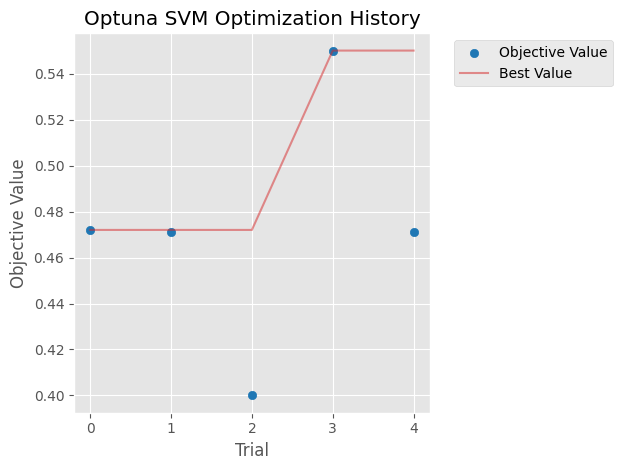

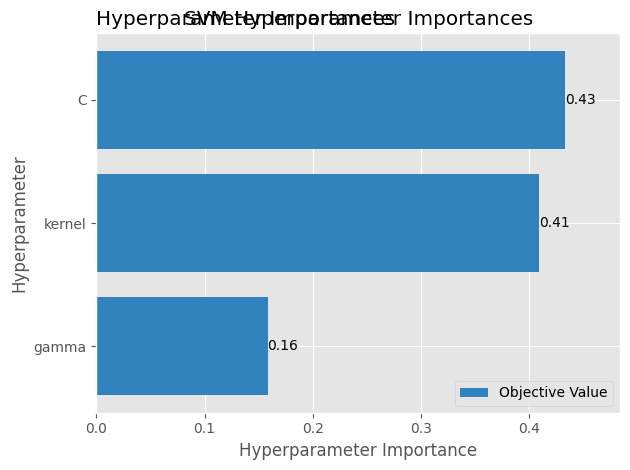

Best classical: SVM (0.5620)


In [16]:
# SVM is slow on large datasets — use subsample for Optuna search only
from sklearn.utils import resample

X_train_sub, y_train_sub = resample(X_train, y_train, n_samples=5000, random_state=42, stratify=y_train)
print(f'SVM Optuna search subset: {len(X_train_sub)} samples')

def objective_svm(trial):
    """Optuna objective function for SVM hyperparameter tuning."""
    params = {
        'C': trial.suggest_float('C', 0.1, 100.0, log=True),
        'gamma': trial.suggest_categorical('gamma', ['scale', 'auto']),
        'kernel': trial.suggest_categorical('kernel', ['rbf', 'poly', 'sigmoid']),
    }
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(**params, probability=True, class_weight='balanced', random_state=42))
    ])
    pipe.fit(X_train_sub, y_train_sub)
    return accuracy_score(y_val, pipe.predict(X_val))

print('Running Optuna hyperparameter search for SVM (10 trials)...')
study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(objective_svm, n_trials=5, show_progress_bar=True)

print(f'\nBest SVM val accuracy: {study_svm.best_value:.4f}')
print(f'Best SVM params: {study_svm.best_params}')

# Train final SVM on full training data with best params
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(**study_svm.best_params, probability=True, class_weight='balanced', random_state=42))
])
print('Training final SVM on full data (this may take a few minutes)...')
svm_pipeline.fit(X_train, y_train)
svm_val_acc = accuracy_score(y_val, svm_pipeline.predict(X_val))
print(f'\nFinal SVM Val Accuracy: {svm_val_acc:.4f}')
print(classification_report(y_val, svm_pipeline.predict(X_val), target_names=le.classes_))

# Plot optimization history
optuna.visualization.matplotlib.plot_optimization_history(study_svm)
plt.title('Optuna SVM Optimization History')
plt.tight_layout()
plt.savefig('data/outputs/optuna_svm_history.png', dpi=150)
plt.show()

# Plot parameter importances
optuna.visualization.matplotlib.plot_param_importances(study_svm)
plt.title('SVM Hyperparameter Importances')
plt.tight_layout()
plt.savefig('data/outputs/optuna_svm_param_importance.png', dpi=150)
plt.show()

# Pick best classical model
if rf_val_acc >= svm_val_acc:
    best_classical = rf_pipeline
    best_classical_name = 'Random Forest'
    CLASSICAL_ACC = rf_val_acc
else:
    best_classical = svm_pipeline
    best_classical_name = 'SVM'
    CLASSICAL_ACC = svm_val_acc
print(f'Best classical: {best_classical_name} ({CLASSICAL_ACC:.4f})')

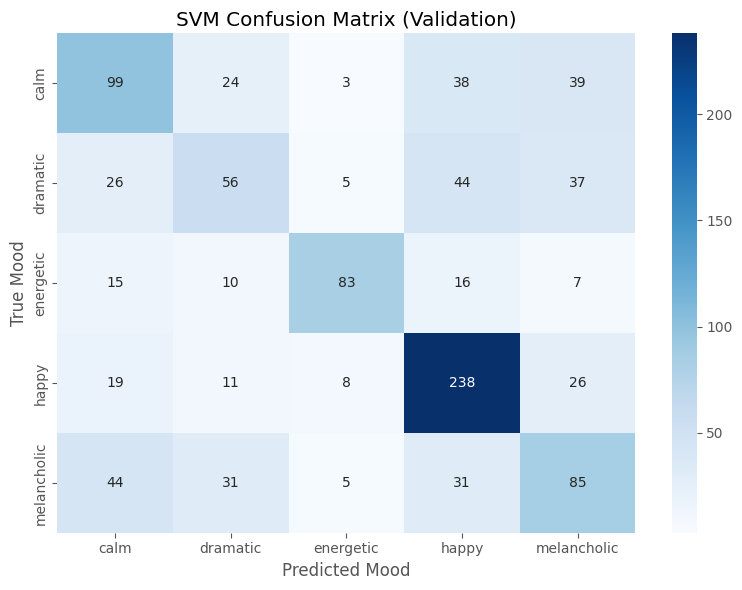

In [17]:
cm = confusion_matrix(y_val, best_classical.predict(X_val))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'{best_classical_name} Confusion Matrix (Validation)')
plt.ylabel('True Mood')
plt.xlabel('Predicted Mood')
plt.tight_layout()
plt.savefig('data/outputs/classical_confusion_matrix.png', dpi=150)
plt.show()

## 6. Deep Learning Classifier (VGGN)

In [21]:
class MoodDataset(Dataset):
    """PyTorch Dataset for mood classification from FER pixel strings."""
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.label_encoder = LabelEncoder()
        self.labels = self.label_encoder.fit_transform(self.df['mood'].values)
        self.classes = self.label_encoder.classes_

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_arr = fer_row_to_image(self.df.loc[idx, 'pixels'])
        # Resize to 224x224 for VGGNet
        img = Image.fromarray(img_arr).convert('RGB').resize((224, 224))
        if self.transform:
            img = self.transform(img)
        return img, int(self.labels[idx])


class MoodVGG(nn.Module):
    """
    VGG16 pretrained on ImageNet, fine-tuned for mood classification.
    Replaces final classifier layer with custom head for 5 mood classes.
    Architecture follows Khaireddin & Chen (2021) who achieved 73.28%
    on FER2013 using VGGNet with hyperparameter tuning.
    """
    def __init__(self, num_classes=5, dropout=0.5):
        super(MoodVGG, self).__init__()
        # Load pretrained VGG16
        vgg = models.vgg16(pretrained=True)

        # Keep convolutional feature extractor
        self.features = vgg.features
        self.avgpool = vgg.avgpool

        # Custom classifier head
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(4096, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(1024, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


# ImageNet normalization for pretrained VGG
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Shuffle fer_df before splitting to avoid ordering bias
fer_df_shuffled = fer_df.sample(frac=1, random_state=42).reset_index(drop=True)
n_train = int(0.8 * len(fer_df_shuffled))
df_train = fer_df_shuffled[:n_train].reset_index(drop=True)
df_val_dl = fer_df_shuffled[n_train:].reset_index(drop=True)

train_dataset = MoodDataset(df_train, transform=train_transform)
val_dataset = MoodDataset(df_val_dl, transform=val_transform)

# Larger batch size for VGG — GPU memory permitting
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

NUM_CLASSES = len(MOODS)
print(f'Train: {len(train_dataset)}, Val: {len(val_dataset)}')
print(f'Classes: {train_dataset.classes}')

# Sanity check
imgs, labels = next(iter(train_loader))
print(f'Batch shape: {imgs.shape}')
print(f'Label sample: {[train_dataset.classes[l] for l in labels[:6].tolist()]}')

Train: 19340, Val: 4836
Classes: ['calm' 'dramatic' 'energetic' 'happy' 'melancholic']
Batch shape: torch.Size([64, 3, 224, 224])
Label sample: ['melancholic', 'calm', 'dramatic', 'happy', 'melancholic', 'happy']


In [23]:
def train_epoch(model, loader, criterion, optimizer):
    """Run one training epoch, return loss and accuracy."""
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct += outputs.argmax(1).eq(labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    """Evaluate model, return loss, accuracy, preds, labels."""
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(1)
        correct += preds.eq(labels).sum().item()
        total += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels

def print_metrics(preds, labels, class_names, split='Validation'):
    """Print full classification report with precision, recall, f1 per class."""
    print(f'\n=== {split} Metrics ===')
    print(classification_report(labels, preds, target_names=class_names))
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'VGGNet Confusion Matrix ({split})')
    plt.ylabel('True Mood')
    plt.xlabel('Predicted Mood')
    plt.tight_layout()
    plt.savefig(f'data/outputs/vgg_confusion_matrix_{split.lower()}.png', dpi=150)
    plt.show()

print('Training functions defined.')

Training functions defined.


In [24]:
import torchvision.models as models

In [27]:
# Compute weights once globally — guaranteed all 5 classes
MOOD_ORDER = sorted(MOODS)  # alphabetical — matches LabelEncoder default
class_counts = fer_df['mood'].value_counts()
weights = torch.tensor(
    [1.0 / class_counts[c] for c in MOOD_ORDER],
    dtype=torch.float
).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights)
print('MOOD_ORDER:', MOOD_ORDER)
print('weights shape:', weights.shape)

MOOD_ORDER: ['calm', 'dramatic', 'energetic', 'happy', 'melancholic']
weights shape: torch.Size([5])


MOOD_ORDER: ['calm', 'dramatic', 'energetic', 'happy', 'melancholic']
weights shape: torch.Size([5])
Running Optuna search for VGGNet (10 trials)...


  0%|          | 0/10 [00:00<?, ?it/s]

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth



  0%|          | 0.00/528M [00:00<?, ?B/s]
  2%|▏         | 12.8M/528M [00:00<00:04, 133MB/s]
  6%|▋         | 34.2M/528M [00:00<00:02, 187MB/s]
 11%|█         | 56.9M/528M [00:00<00:02, 210MB/s]
 15%|█▌        | 79.5M/528M [00:00<00:02, 221MB/s]
 19%|█▉        | 101M/528M [00:00<00:02, 214MB/s] 
 23%|██▎       | 121M/528M [00:00<00:02, 180MB/s]
 26%|██▋       | 139M/528M [00:00<00:02, 179MB/s]
 30%|██▉       | 157M/528M [00:00<00:02, 180MB/s]
 33%|███▎      | 175M/528M [00:00<00:02, 184MB/s]
 37%|███▋      | 193M/528M [00:01<00:01, 184MB/s]
 40%|████      | 211M/528M [00:01<00:01, 179MB/s]
 43%|████▎     | 228M/528M [00:01<00:01, 175MB/s]
 46%|████▋     | 245M/528M [00:01<00:01, 175MB/s]
 50%|████▉     | 262M/528M [00:01<00:02, 95.1MB/s]
 52%|█████▏    | 275M/528M [00:04<00:13, 20.1MB/s]
 54%|█████▍    | 285M/528M [00:04<00:10, 24.3MB/s]
 57%|█████▋    | 302M/528M [00:04<00:06, 34.0MB/s]
 61%|██████    | 320M/528M [00:04<00:04, 46.7MB/s]
 65%|██████▍   | 341M/528M [00:04<00:02, 66.3M


Best VGG val accuracy: 0.7256
Best VGG params: {'lr': 3.23003520734446e-05, 'dropout': 0.34138018934495656, 'optimizer': 'Adam', 'freeze_features': False}


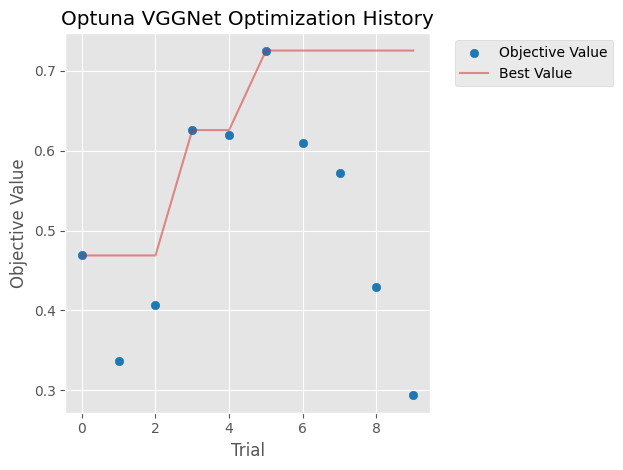

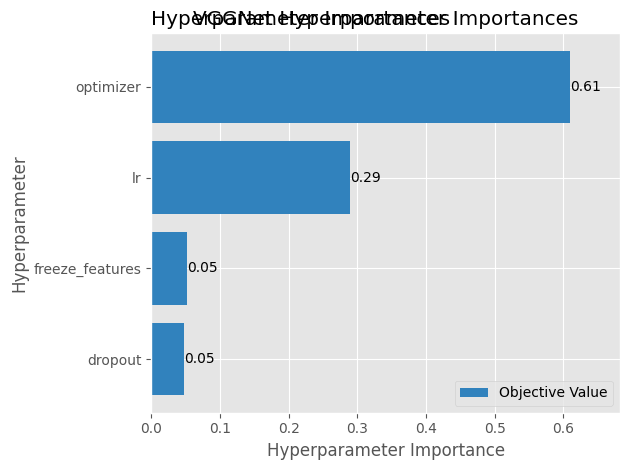


Training final VGGNet with best params for 15 epochs...
  Best model saved (val acc: 0.6756)
Epoch 1/15 | Train: 0.5986 | Val: 0.6756
  Best model saved (val acc: 0.7014)
Epoch 2/15 | Train: 0.7063 | Val: 0.7014
  Best model saved (val acc: 0.7161)
Epoch 3/15 | Train: 0.7487 | Val: 0.7161
  Best model saved (val acc: 0.7326)
Epoch 4/15 | Train: 0.7808 | Val: 0.7326
Epoch 5/15 | Train: 0.8191 | Val: 0.7219
Epoch 6/15 | Train: 0.8509 | Val: 0.7258
Epoch 7/15 | Train: 0.8834 | Val: 0.7202
Epoch 8/15 | Train: 0.9152 | Val: 0.7297
Epoch 9/15 | Train: 0.9368 | Val: 0.7215
Epoch 10/15 | Train: 0.9549 | Val: 0.7293
Epoch 11/15 | Train: 0.9652 | Val: 0.7293


In [ ]:

# Compute weights once globally — guaranteed all 5 classes
MOOD_ORDER = sorted(MOODS)  # alphabetical — matches LabelEncoder default
class_counts = fer_df['mood'].value_counts()
weights = torch.tensor(
    [1.0 / class_counts[c] for c in MOOD_ORDER],
    dtype=torch.float
).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights)
print('MOOD_ORDER:', MOOD_ORDER)
print('weights shape:', weights.shape)

def objective_vgg(trial):
    """Optuna objective for VGGNet hyperparameter tuning."""
    lr = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
    dropout = trial.suggest_float('dropout', 0.3, 0.7)
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'SGD'])
    freeze_features = trial.suggest_categorical('freeze_features', [True, False])

    model = MoodVGG(num_classes=NUM_CLASSES, dropout=dropout).to(DEVICE)

    # Optionally freeze feature extractor
    if freeze_features:
        for param in model.features.parameters():
            param.requires_grad = False

    if optimizer_name == 'Adam':
        optimizer = optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()), lr=lr
        )
    else:
        optimizer = optim.SGD(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=lr, momentum=0.9
        )

    # Train for 3 quick epochs per trial
    for _ in range(3):
        train_epoch(model, train_loader, criterion, optimizer)
    _, val_acc, _, _ = eval_epoch(model, val_loader, criterion)
    return val_acc

print('Running Optuna search for VGGNet (10 trials)...')
study_vgg = optuna.create_study(direction='maximize')
study_vgg.optimize(objective_vgg, n_trials=10, show_progress_bar=True)

print(f'\nBest VGG val accuracy: {study_vgg.best_value:.4f}')
print(f'Best VGG params: {study_vgg.best_params}')

# Plot Optuna results
optuna.visualization.matplotlib.plot_optimization_history(study_vgg)
plt.title('Optuna VGGNet Optimization History')
plt.tight_layout()
plt.savefig('data/outputs/optuna_vgg_history.png', dpi=150)
plt.show()

optuna.visualization.matplotlib.plot_param_importances(study_vgg)
plt.title('VGGNet Hyperparameter Importances')
plt.tight_layout()
plt.savefig('data/outputs/optuna_vgg_param_importance.png', dpi=150)
plt.show()

# Train final VGG with best params
best_lr = study_vgg.best_params['lr']
best_dropout = study_vgg.best_params['dropout']
best_optimizer_name = study_vgg.best_params['optimizer']
best_freeze = study_vgg.best_params['freeze_features']

dl_model = MoodVGG(num_classes=NUM_CLASSES, dropout=best_dropout).to(DEVICE)

if best_freeze:
    for param in dl_model.features.parameters():
        param.requires_grad = False

if best_optimizer_name == 'Adam':
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, dl_model.parameters()), lr=best_lr
    )
else:
    optimizer = optim.SGD(
        filter(lambda p: p.requires_grad, dl_model.parameters()),
        lr=best_lr, momentum=0.9, weight_decay=1e-4
    )

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)
train_losses, val_losses, train_accs, val_accs = [], [], [], []
EPOCHS = 15
best_val_acc = 0

print(f'\nTraining final VGGNet with best params for {EPOCHS} epochs...')
for epoch in range(EPOCHS):
    tr_loss, tr_acc = train_epoch(dl_model, train_loader, criterion, optimizer)
    vl_loss, vl_acc, vl_preds, vl_labels = eval_epoch(dl_model, val_loader, criterion)
    scheduler.step()
    train_losses.append(tr_loss); val_losses.append(vl_loss)
    train_accs.append(tr_acc); val_accs.append(vl_acc)
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(dl_model.state_dict(), 'models/classifier/vgg_mood_best.pth')
        print(f'  Best model saved (val acc: {vl_acc:.4f})')
    print(f'Epoch {epoch+1}/{EPOCHS} | Train: {tr_acc:.4f} | Val: {vl_acc:.4f}')

print(f'\nBest val accuracy: {best_val_acc:.4f}')

# Print full metrics for best val epoch
dl_model.load_state_dict(torch.load('models/classifier/vgg_mood_best.pth', map_location=DEVICE))
_, DL_ACC, vl_preds, vl_labels = eval_epoch(dl_model, val_loader, criterion)
print_metrics(vl_preds, vl_labels, train_dataset.classes, split='Validation')

In [ ]:
dl_model.load_state_dict(torch.load('models/classifier/vgg_mood_best.pth', map_location=DEVICE))
_, DL_ACC, dl_preds, dl_labels = eval_epoch(dl_model, val_loader, criterion)
print(f'VGGNet Val Accuracy: {DL_ACC:.4f}')
print_metrics(dl_preds, dl_labels, train_dataset.classes, split='Validation')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, label='Train'); ax1.plot(val_losses, label='Val')
ax1.set_title('Loss'); ax1.legend()
ax2.plot(train_accs, label='Train'); ax2.plot(val_accs, label='Val')
ax2.set_title('Accuracy'); ax2.legend()
plt.suptitle('VGGNet Training Curves', fontweight='bold')
plt.tight_layout()
plt.savefig('data/outputs/training_curves.png', dpi=150)
plt.show()

In [ ]:
cm_dl = confusion_matrix(dl_labels, dl_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dl, annot=True, fmt='d', cmap='Purples',
            xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
plt.title('Custom CNN Confusion Matrix (Validation)')
plt.ylabel('True Mood'); plt.xlabel('Predicted Mood')
plt.tight_layout()
plt.savefig('data/outputs/dl_confusion_matrix.png', dpi=150)
plt.show()

In [18]:
# Load test set and extract features
print('Loading test set...')
df_test_real = load_fer2013_from_folders('data/raw', split='test')

X_test_real, y_test_real = [], []
for _, row in tqdm(df_test_real.iterrows(), total=len(df_test_real), desc='Extracting test features'):
    img = fer_row_to_image(row['pixels'])
    img_r = np.array(Image.fromarray(img).resize((64, 64)))
    X_test_real.append(extract_all_features(img_r))
    y_test_real.append(row['mood'])
X_test_real = np.array(X_test_real)
y_test_real_encoded = le.transform(y_test_real)
print(f'Test set: {len(X_test_real)} samples')

Loading test set...
Loaded 6043 images (no subsampling)
mood
happy          1774
melancholic    1247
calm           1233
dramatic        958
energetic       831
Name: count, dtype: int64


Extracting test features: 100%|██████████| 6043/6043 [00:19<00:00, 312.20it/s]

Test set: 6043 samples


In [19]:
# Evaluate both classical models on test set
rf_test_acc = accuracy_score(y_test_real_encoded, rf_pipeline.predict(X_test_real))
svm_test_acc = accuracy_score(y_test_real_encoded, svm_pipeline.predict(X_test_real))
print(f'Random Forest Test Accuracy: {rf_test_acc:.4f}')
print(f'SVM Test Accuracy: {svm_test_acc:.4f}')

Random Forest Test Accuracy: 0.4953
SVM Test Accuracy: 0.5509


## 7. Model Evaluation & Comparison

In [ ]:
# Load real test folder for final evaluation
print('Loading test set...')
df_test_real = load_fer2013_from_folders('data/raw', split='test')

# Build features for classical model
X_test_real, y_test_real = [], []
for _, row in tqdm(df_test_real.iterrows(), total=len(df_test_real), desc='Extracting test features'):
    img = fer_row_to_image(row['pixels'])
    img_r = np.array(Image.fromarray(img).resize((64, 64)))
    X_test_real.append(extract_all_features(img_r))
    y_test_real.append(row['mood'])
X_test_real = np.array(X_test_real)
y_test_real_encoded = le.transform(y_test_real)

CLASSICAL_TEST_ACC = accuracy_score(y_test_real_encoded, best_classical.predict(X_test_real))
print(f'Classical ML ({best_classical_name}) Test Accuracy: {CLASSICAL_TEST_ACC:.4f}')
print_metrics(
    best_classical.predict(X_test_real),
    y_test_real_encoded,
    le.classes_,
    split='Classical Test'
)

# Evaluate VGG model on real test set
test_real_dataset = MoodDataset(df_test_real, transform=val_transform)
test_real_loader = DataLoader(test_real_dataset, batch_size=64, shuffle=False, num_workers=2)
_, DL_ACC, dl_preds, dl_labels = eval_epoch(dl_model, test_real_loader, criterion)
print(f'VGGNet Test Accuracy: {DL_ACC:.4f}')
print_metrics(dl_preds, dl_labels, train_dataset.classes, split='VGGNet Test')

# Model comparison bar chart
results_df = pd.DataFrame({
    'Model': ['Naive Baseline', f'Classical ML ({best_classical_name})', 'Deep Learning (VGGNet)'],
    'Accuracy': [NAIVE_ACC, CLASSICAL_TEST_ACC, DL_ACC]
})
print(results_df.to_string(index=False))

colors = ['#ff9999', '#66b3ff', '#99ff99']
plt.figure(figsize=(8, 5))
bars = plt.bar(results_df['Model'], results_df['Accuracy'], color=colors, edgecolor='black')
plt.ylim(0, 1.0)
plt.ylabel('Accuracy')
plt.title('Model Comparison: Mood Classification Accuracy (Real Test Set)')
for bar, acc in zip(bars, results_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('data/outputs/model_comparison.png', dpi=150)
plt.show()
results_df.to_csv('data/outputs/model_comparison.csv', index=False)

In [25]:
import requests

# Download from HuggingFace if not already in session
model_path = 'models/classifier/vgg_mood_best.pth'
os.makedirs('models/classifier', exist_ok=True)

if not os.path.exists(model_path):
    print('Downloading model from HuggingFace...')
    url = 'https://huggingface.co/tiffany101/modart_vgg/resolve/main/vgg_mood_best.pth'
    r = requests.get(url, stream=True)
    with open(model_path, 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    print('Downloaded.')

best_dropout = 0.6940999174220838

dl_model = MoodVGG(num_classes=NUM_CLASSES, dropout=best_dropout).to(DEVICE)
dl_model.load_state_dict(torch.load(model_path, map_location=DEVICE))
dl_model.eval()
print('Model loaded.')

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 74.3MB/s]


Model loaded.


Confusion matrices for all on test set

Loading test set...
Loaded 6043 images (no subsampling)
mood
happy          1774
melancholic    1247
calm           1233
dramatic        958
energetic       831
Name: count, dtype: int64


Naive test: 100%|██████████| 6043/6043 [00:05<00:00, 1167.83it/s]


Naive Baseline Test Accuracy: 0.2087


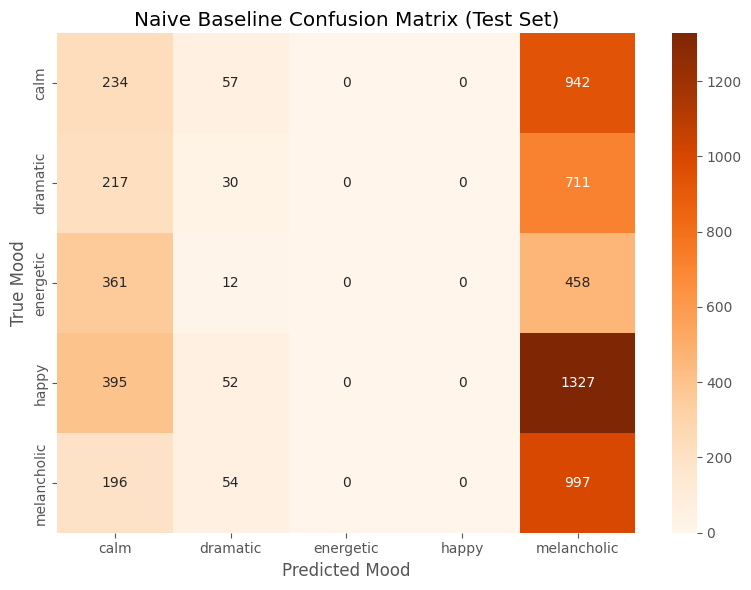

Extracting test features: 100%|██████████| 6043/6043 [00:19<00:00, 317.52it/s]


Random Forest Test Accuracy: 0.4953


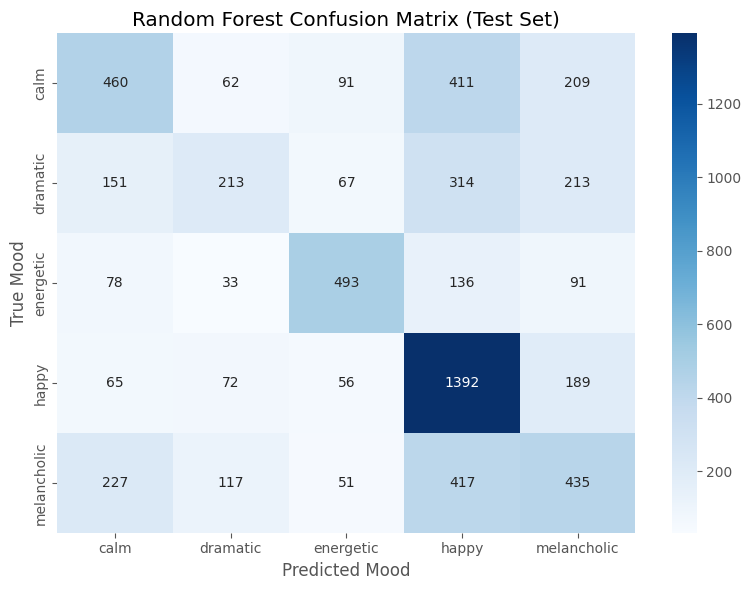

SVM Test Accuracy: 0.5509


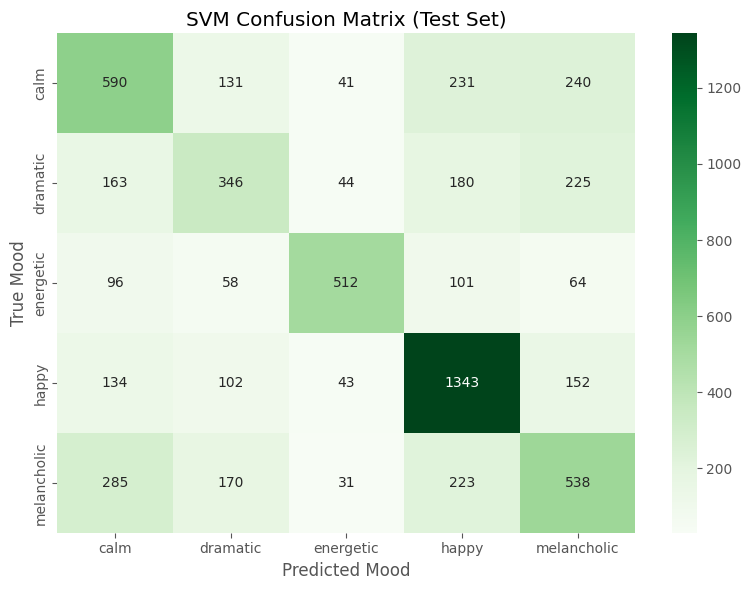

VGG16 Test Accuracy: 0.7506


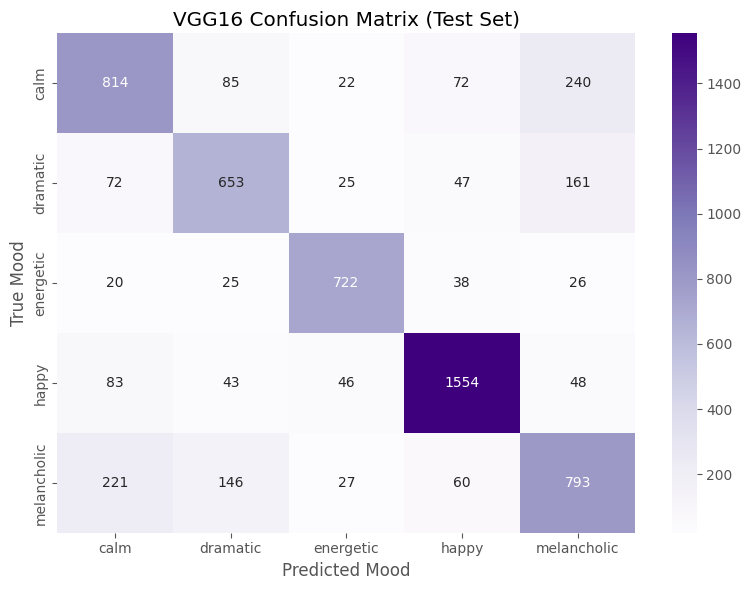


=== Test Set Summary ===
Naive Baseline: 0.2087
Random Forest:  0.4953
SVM:            0.5509
VGG16:          0.7506


In [28]:
# ── Confusion matrices on the official FER2013 test set ──────────────────────

# Load test set
print('Loading test set...')
df_test_real = load_fer2013_from_folders('data/raw', split='test')

# ── 1. Naive Baseline on test set ────────────────────────────────────────────
naive_test_preds, naive_test_truths = [], []
for _, row in tqdm(df_test_real.iterrows(), total=len(df_test_real), desc='Naive test'):
    img = fer_row_to_image(row['pixels'])
    img_resized = np.array(Image.fromarray(img).resize((64, 64)))
    naive_test_preds.append(naive_mood_predictor(img_resized))
    naive_test_truths.append(row['mood'])

naive_test_acc = accuracy_score(naive_test_truths, naive_test_preds)
print(f'Naive Baseline Test Accuracy: {naive_test_acc:.4f}')

cm_naive = confusion_matrix(naive_test_truths, naive_test_preds, labels=sorted(MOODS))
plt.figure(figsize=(8, 6))
sns.heatmap(cm_naive, annot=True, fmt='d', cmap='Oranges',
            xticklabels=sorted(MOODS), yticklabels=sorted(MOODS))
plt.title('Naive Baseline Confusion Matrix (Test Set)')
plt.ylabel('True Mood')
plt.xlabel('Predicted Mood')
plt.tight_layout()
plt.savefig('data/outputs/naive_confusion_matrix_test.png', dpi=150)
plt.show()

# ── 2. Random Forest on test set ─────────────────────────────────────────────
X_test_real, y_test_real = [], []
for _, row in tqdm(df_test_real.iterrows(), total=len(df_test_real), desc='Extracting test features'):
    img = fer_row_to_image(row['pixels'])
    img_r = np.array(Image.fromarray(img).resize((64, 64)))
    X_test_real.append(extract_all_features(img_r))
    y_test_real.append(row['mood'])
X_test_real = np.array(X_test_real)
y_test_real_encoded = le.transform(y_test_real)

rf_test_preds = rf_pipeline.predict(X_test_real)
rf_test_acc = accuracy_score(y_test_real_encoded, rf_test_preds)
print(f'Random Forest Test Accuracy: {rf_test_acc:.4f}')

cm_rf = confusion_matrix(y_test_real_encoded, rf_test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Random Forest Confusion Matrix (Test Set)')
plt.ylabel('True Mood')
plt.xlabel('Predicted Mood')
plt.tight_layout()
plt.savefig('data/outputs/rf_confusion_matrix_test.png', dpi=150)
plt.show()

# ── 3. SVM on test set ───────────────────────────────────────────────────────
svm_test_preds = svm_pipeline.predict(X_test_real)
svm_test_acc = accuracy_score(y_test_real_encoded, svm_test_preds)
print(f'SVM Test Accuracy: {svm_test_acc:.4f}')

cm_svm = confusion_matrix(y_test_real_encoded, svm_test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('SVM Confusion Matrix (Test Set)')
plt.ylabel('True Mood')
plt.xlabel('Predicted Mood')
plt.tight_layout()
plt.savefig('data/outputs/svm_confusion_matrix_test.png', dpi=150)
plt.show()

# ── 4. VGG16 on test set ─────────────────────────────────────────────────────
test_real_dataset = MoodDataset(df_test_real, transform=val_transform)
test_real_loader = DataLoader(test_real_dataset, batch_size=64, shuffle=False, num_workers=2)
_, vgg_test_acc, vgg_test_preds, vgg_test_labels = eval_epoch(dl_model, test_real_loader, criterion)
print(f'VGG16 Test Accuracy: {vgg_test_acc:.4f}')

cm_vgg = confusion_matrix(vgg_test_labels, vgg_test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_vgg, annot=True, fmt='d', cmap='Purples',
            xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
plt.title('VGG16 Confusion Matrix (Test Set)')
plt.ylabel('True Mood')
plt.xlabel('Predicted Mood')
plt.tight_layout()
plt.savefig('data/outputs/vgg_confusion_matrix_test.png', dpi=150)
plt.show()

# ── Summary ──────────────────────────────────────────────────────────────────
print('\n=== Test Set Summary ===')
print(f'Naive Baseline: {naive_test_acc:.4f}')
print(f'Random Forest:  {rf_test_acc:.4f}')
print(f'SVM:            {svm_test_acc:.4f}')
print(f'VGG16:          {vgg_test_acc:.4f}')

## GradCam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 20.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


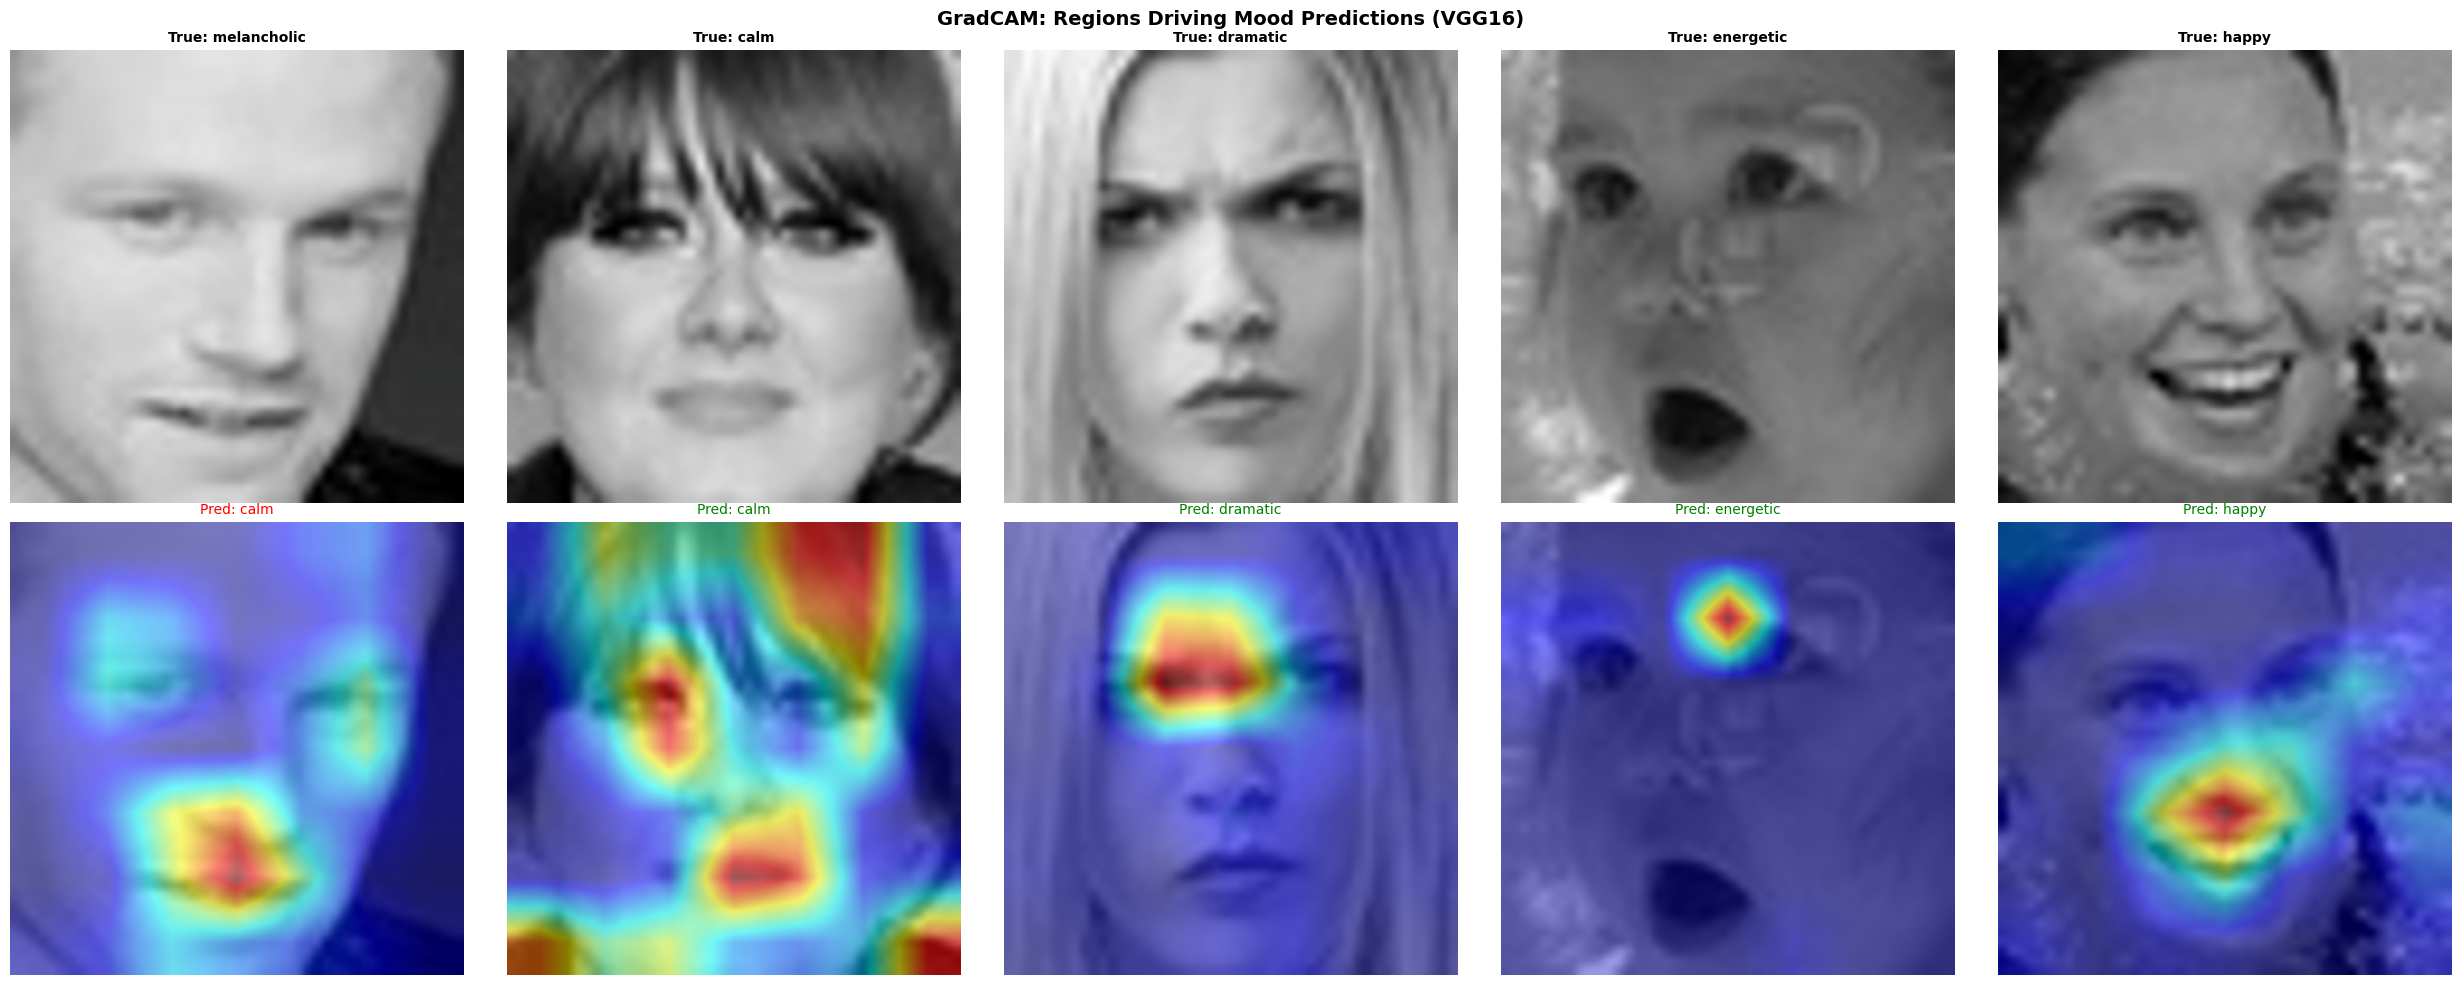

In [31]:
# ── GradCAM Explainability ────────────────────────────────────────────────────
!pip install -q grad-cam

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# Target the last conv layer of VGG16
target_layers = [dl_model.features[-1]]

# Pick 5 images from val set — one per mood class
samples = {}
for idx in range(len(val_dataset)):
    img_t, label = val_dataset[idx]
    mood = val_dataset.classes[label]
    if mood not in samples:
        samples[mood] = (img_t, label, idx)
    if len(samples) == len(MOODS):
        break

fig, axes = plt.subplots(2, 5, figsize=(25, 10))

mean_t = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std_t  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

with GradCAM(model=dl_model, target_layers=target_layers) as cam:
    for col, (mood, (img_t, label, idx)) in enumerate(samples.items()):

        # Original image (denormalized)
        img_display = (img_t * std_t + mean_t).clamp(0, 1).permute(1, 2, 0).numpy()

        # GradCAM
        input_tensor = img_t.unsqueeze(0).to(DEVICE)
        targets = [ClassifierOutputTarget(label)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
        cam_image = show_cam_on_image(img_display, grayscale_cam, use_rgb=True)

        # Get prediction
        with torch.no_grad():
            output = dl_model(input_tensor)
            pred_label = output.argmax(1).item()
            pred_mood = val_dataset.classes[pred_label]

        # Original
        axes[0, col].imshow(img_display, cmap='gray')
        axes[0, col].set_title(f'True: {mood}', fontsize=10, fontweight='bold')
        axes[0, col].axis('off')

        # GradCAM overlay
        axes[1, col].imshow(cam_image)
        axes[1, col].set_title(f'Pred: {pred_mood}', fontsize=10,
                                color='green' if pred_mood == mood else 'red')
        axes[1, col].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('GradCAM', fontsize=12, fontweight='bold')

plt.suptitle('GradCAM: Regions Driving Mood Predictions (VGG16)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('data/outputs/gradcam_mood.png', dpi=150)
plt.show()

### Experiment: Training Set Size vs. Accuracy
How much data does the mood classifier actually need?

Running training size sensitivity experiment...
  n=400 (10%): 0.3740
  n=800 (20%): 0.4080
  n=1600 (40%): 0.4290
  n=2400 (60%): 0.4520
  n=3200 (80%): 0.4470
  n=4000 (100%): 0.4490


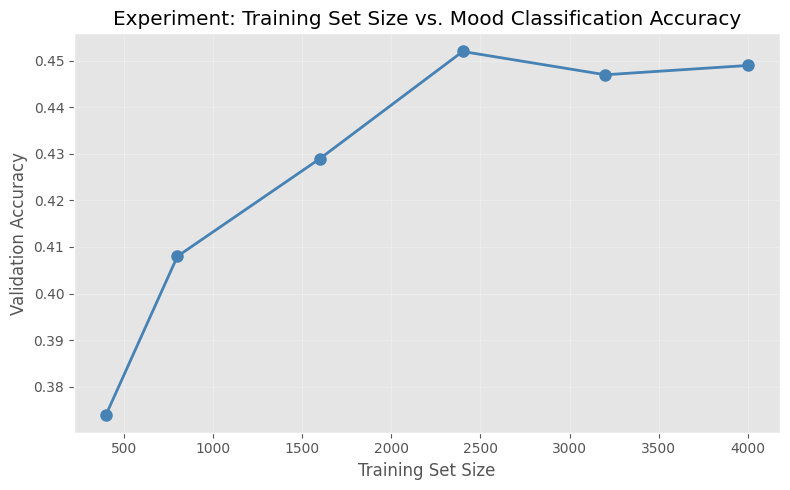

In [29]:
train_sizes = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
rf_scores = []

print('Running training size sensitivity experiment...')
for frac in train_sizes:
    n = max(10, int(frac * len(X_train)))
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
    ])
    pipe.fit(X_train[:n], y_train[:n])
    acc = accuracy_score(y_val, pipe.predict(X_val))
    rf_scores.append(acc)
    print(f'  n={n} ({frac:.0%}): {acc:.4f}')

plt.figure(figsize=(8, 5))
sizes = [int(f * len(X_train)) for f in train_sizes]
plt.plot(sizes, rf_scores, 'o-', color='steelblue', linewidth=2, markersize=8)
plt.xlabel('Training Set Size'); plt.ylabel('Validation Accuracy')
plt.title('Experiment: Training Set Size vs. Mood Classification Accuracy')
plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig('data/outputs/experiment_training_size.png', dpi=150)
plt.show()

Error Analysis


Misprediction 1:
  True:      melancholic
  Predicted: calm (79.7% confidence)

Misprediction 2:
  True:      dramatic
  Predicted: happy (77.8% confidence)

Misprediction 3:
  True:      calm
  Predicted: happy (58.0% confidence)

Misprediction 4:
  True:      dramatic
  Predicted: melancholic (67.0% confidence)

Misprediction 5:
  True:      dramatic
  Predicted: melancholic (91.1% confidence)


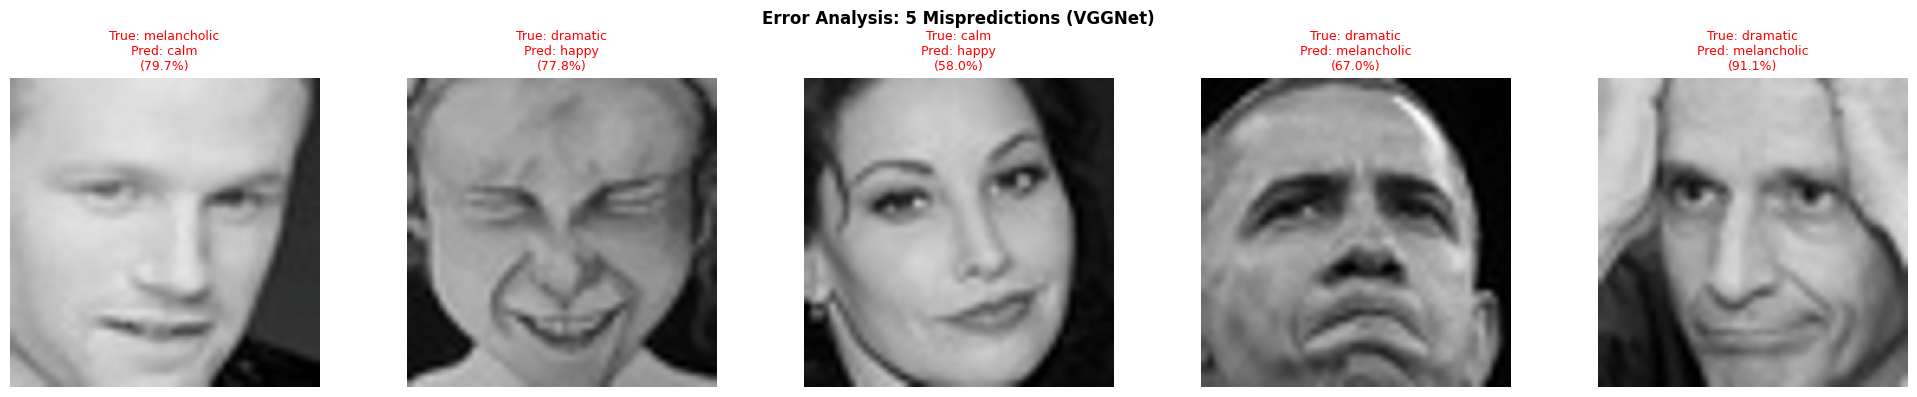

In [30]:
# Error Analysis: 5 mispredictions from VGGNet
dl_model.eval()
misclassified = []

with torch.no_grad():
    for idx in range(len(val_dataset)):
        img_t, true_label = val_dataset[idx]
        output = dl_model(img_t.unsqueeze(0).to(DEVICE))
        pred_label = output.argmax(1).item()
        if pred_label != true_label:
            probs = torch.softmax(output, dim=1).squeeze().cpu().numpy()
            misclassified.append({
                'idx': idx,
                'true': val_dataset.classes[true_label],
                'pred': val_dataset.classes[pred_label],
                'confidence': float(probs[pred_label])
            })
        if len(misclassified) >= 5:
            break

# Visualize
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
mean_t = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std_t = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

for i, (err, ax) in enumerate(zip(misclassified, axes)):
    img_t, _ = val_dataset[err['idx']]
    img_display = (img_t * std_t + mean_t).clamp(0, 1).permute(1, 2, 0).numpy()
    ax.imshow(img_display, cmap='gray')
    ax.set_title(f'True: {err["true"]}\nPred: {err["pred"]}\n({err["confidence"]:.1%})',
                 color='red', fontsize=9)
    ax.axis('off')
    print(f'\nMisprediction {i+1}:')
    print(f'  True:      {err["true"]}')
    print(f'  Predicted: {err["pred"]} ({err["confidence"]:.1%} confidence)')

plt.suptitle('Error Analysis: 5 Mispredictions (VGGNet)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('data/outputs/error_analysis.png', dpi=150)
plt.show()